Run after total description of cores. Here negligible features are recognized

In [ ]:
from notebook_utils import cd2parent
cd2parent()

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Descriptors3D

from src.plot_utils import gradientbars_sliced, truncate_colormap
from src.dataloader import Dataloader

In [3]:
dataloader = Dataloader()

In [4]:
dataloader.load_cores()
dataloader.load_descriptions()
dataloader.load_dft_mols()

In [5]:
cores_df = dataloader.cores.set_index('smiles')
cores_df

,name,label
smiles,,
C1NCC12CNO2,"1-oxa-2,6-diazaspiro[3.3]heptane",spiro
C1NCC12CNC2,"2,6-diazaspiro[3.3]heptane",spiro
C1NCC12COC2,2-oxa-6-azaspiro[3.3]heptane,spiro
C1CC2(CNC2)N1,"1,6-diazaspiro[3.3]heptane",spiro
C1CNC2(C1)CNC2,"2,5-diazaspiro[3.4]octane",spiro
...,...,...
C1NCC12CN2,"1,5-diazaspiro[2.3]hexane",spiro
C1CC12CNC2,5-azaspiro[2.3]hexane,spiro
C1CC2(C1)CO2,1-oxaspiro[2.3]hexane,spiro


In [6]:
descriptions = dataloader.descriptions.set_index('smiles')
descriptions

,QeD,logP,TPSA,SMR_VSA3,SlogP_VSA3,MR,NumNatoms,NumOatoms,dipole,3Dscore,...,PMI2,PMI3,NPR1,NPR2,RadiusOfGyration,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF
smiles,,,,,,,,,,,,,,,,,,,,,
C1NCC12CNO2,0.403605,-1.1368,33.29,10.782935,4.837589,24.6884,2,1,3.87714,1.321493,...,248.386224,249.438373,0.325711,0.995782,1.700543,0.012257,0.945469,0.335358,0.507082,0.718026
C1NCC12CNC2,0.413406,-0.8208,24.06,10.619627,0.000000,28.1724,2,0,1.99457,1.330566,...,251.380272,253.225122,0.337851,0.992715,1.733908,0.011604,0.941199,0.319372,0.661015,0.766013
C1NCC12COC2,0.446167,-0.3938,21.26,5.309813,4.736863,26.1217,1,1,2.52334,1.321108,...,255.643938,256.254574,0.323491,0.997617,1.732046,0.012035,0.946231,0.338602,0.737560,0.798354
C1CC2(CNC2)N1,0.419327,-0.6783,24.06,10.619627,0.000000,28.2204,2,0,2.26480,1.338306,...,245.727260,247.974699,0.347370,0.990937,1.718686,0.011504,0.937728,0.307329,0.539355,0.699706
C1CNC2(C1)CNC2,0.449822,-0.2882,24.06,10.619627,0.000000,32.8374,2,0,1.15946,1.304794,...,313.077066,332.667135,0.363682,0.941112,1.848656,0.007779,0.931523,0.279286,0.605799,0.834604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C1NCC12CN2,0.366447,-1.0684,33.97,10.619627,0.000000,23.6034,2,0,2.80086,1.240647,...,166.522721,185.717503,0.344002,0.896645,1.572691,0.014035,0.938969,0.297353,0.448359,0.647464
C1CC12CNC2,0.445886,0.3698,12.03,5.309813,0.000000,24.5367,1,0,1.48063,1.260854,...,169.878248,187.622474,0.355428,0.905426,1.597255,0.013577,0.934704,0.284426,0.529917,0.712683
C1CC2(C1)CO2,0.397789,0.9393,12.53,0.000000,4.736863,22.5340,0,1,2.19762,1.249874,...,165.949763,185.283819,0.354223,0.895652,1.574122,0.013647,0.935161,0.284896,0.426321,0.593223


In [11]:
mols = dataloader.dft_mols.copy()
mols.index = cores_df.index

In [12]:
mols

smiles
C1NCC12CNO2       <rdkit.Chem.rdchem.Mol object at 0x7fedf2c21690>
C1NCC12CNC2       <rdkit.Chem.rdchem.Mol object at 0x7fedf2c21070>
C1NCC12COC2       <rdkit.Chem.rdchem.Mol object at 0x7fedf2c20900>
C1CC2(CNC2)N1     <rdkit.Chem.rdchem.Mol object at 0x7fed8cb57060>
C1CNC2(C1)CNC2    <rdkit.Chem.rdchem.Mol object at 0x7fed8cb570d0>
                                        ...                       
C1NCC12CN2        <rdkit.Chem.rdchem.Mol object at 0x7fed8cbdcac0>
C1CC12CNC2        <rdkit.Chem.rdchem.Mol object at 0x7fed8cbdcb30>
C1CC2(C1)CO2      <rdkit.Chem.rdchem.Mol object at 0x7fed8cbdcba0>
C1CC2(C1)CN2      <rdkit.Chem.rdchem.Mol object at 0x7fed8cbdcc10>
C1CC2(C1)CC2      <rdkit.Chem.rdchem.Mol object at 0x7fed8cbdcc80>
Name: mol, Length: 71, dtype: object

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
descriptionsScaled = scaler.fit_transform(descriptions)
descriptionsScaled = pd.DataFrame(descriptionsScaled, columns=descriptions.columns, index=descriptions.index)
descriptionsScaled

,QeD,logP,TPSA,SMR_VSA3,SlogP_VSA3,MR,NumNatoms,NumOatoms,dipole,3Dscore,...,PMI2,PMI3,NPR1,NPR2,RadiusOfGyration,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF
smiles,,,,,,,,,,,,,,,,,,,,,
C1NCC12CNO2,0.202634,0.143772,0.571993,0.695664,0.372302,0.271171,1.0,0.5,0.763046,0.335035,...,0.309423,0.205671,0.046316,0.996288,0.448407,0.769439,0.985605,0.905378,0.568310,0.626502
C1NCC12CNC2,0.255992,0.231411,0.413402,0.685128,0.000000,0.386591,1.0,0.0,0.392542,0.344490,...,0.314154,0.211022,0.064320,0.990084,0.479973,0.715486,0.979572,0.862173,0.740830,0.668373
C1NCC12COC2,0.434356,0.349835,0.365292,0.342564,0.364550,0.318654,0.5,0.5,0.496608,0.334634,...,0.320891,0.215303,0.043023,1.000000,0.478210,0.751097,0.986682,0.914145,0.826617,0.696593
C1CC2(CNC2)N1,0.288226,0.270932,0.413402,0.685128,0.000000,0.388181,1.0,0.0,0.445725,0.352557,...,0.305222,0.203602,0.078435,0.986488,0.465571,0.707253,0.974668,0.829626,0.604480,0.610516
C1CNC2(C1)CNC2,0.454252,0.379122,0.413402,0.685128,0.000000,0.541136,1.0,0.0,0.228186,0.317633,...,0.411638,0.323290,0.102626,0.885709,0.588531,0.399452,0.965901,0.753838,0.678946,0.728223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C1NCC12CN2,0.000333,0.162742,0.583677,0.685128,0.000000,0.235226,1.0,0.0,0.551226,0.250784,...,0.180075,0.115620,0.073441,0.795768,0.327451,0.916372,0.976421,0.802666,0.502496,0.564932
C1CC12CNC2,0.432827,0.561611,0.206701,0.342564,0.000000,0.266145,0.5,0.0,0.291395,0.271841,...,0.185377,0.118312,0.090385,0.813528,0.350690,0.878577,0.970395,0.767729,0.593902,0.621839
C1CC2(C1)CO2,0.170965,0.719555,0.215292,0.000000,0.364550,0.199799,0.0,0.5,0.432504,0.260400,...,0.179169,0.115007,0.088598,0.793758,0.328805,0.884297,0.971041,0.769000,0.477797,0.517603


## Molecular Shape

In [ ]:
PM = cores_df.copy()
PM["PMx"]=mols.apply(Descriptors3D.NPR1)
PM["PMy"]=mols.apply(Descriptors3D.NPR2)
PM

,name,label,PMx,PMy
smiles,,,,
C1NCC12CNO2,"1-oxa-2,6-diazaspiro[3.3]heptane",spiro,0.325711,0.995782
C1NCC12CNC2,"2,6-diazaspiro[3.3]heptane",spiro,0.337851,0.992715
C1NCC12COC2,2-oxa-6-azaspiro[3.3]heptane,spiro,0.323491,0.997617
C1CC2(CNC2)N1,"1,6-diazaspiro[3.3]heptane",spiro,0.347370,0.990937
C1CNC2(C1)CNC2,"2,5-diazaspiro[3.4]octane",spiro,0.363682,0.941112
...,...,...,...,...
C1NCC12CN2,"1,5-diazaspiro[2.3]hexane",spiro,0.344002,0.896645
C1CC12CNC2,5-azaspiro[2.3]hexane,spiro,0.355428,0.905426
C1CC2(C1)CO2,1-oxaspiro[2.3]hexane,spiro,0.354223,0.895652


In [14]:
PM.head()

,name,label,PMx,PMy
smiles,,,,
C1NCC12CNO2,"1-oxa-2,6-diazaspiro[3.3]heptane",spiro,0.325711,0.995782
C1NCC12CNC2,"2,6-diazaspiro[3.3]heptane",spiro,0.337851,0.992715
C1NCC12COC2,2-oxa-6-azaspiro[3.3]heptane,spiro,0.323491,0.997617
C1CC2(CNC2)N1,"1,6-diazaspiro[3.3]heptane",spiro,0.347370,0.990937
C1CNC2(C1)CNC2,"2,5-diazaspiro[3.4]octane",spiro,0.363682,0.941112


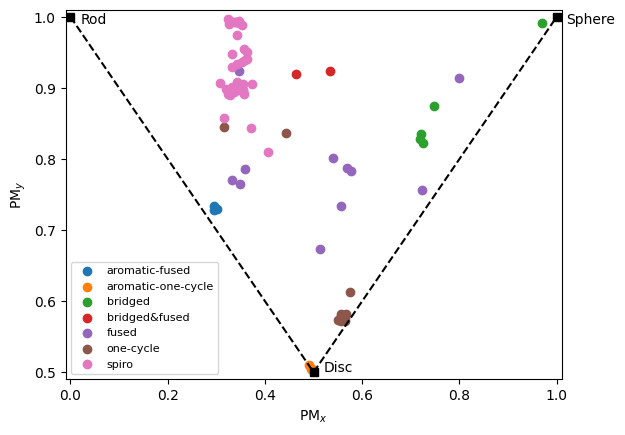

In [ ]:
special_cores=[
    # TODO add here special scatter point relative to extra cores.
    # 'C1NCC12CNO2',
]

for typ, idxs in PM.groupby("label").groups.items():
	idxs = [idx for idx in idxs if idx not in special_cores]
	plt.scatter(*PM.loc[idxs,["PMx","PMy"]].T.values, label=typ)

for special in special_cores:
	plt.scatter(*PM.loc[special,["PMx","PMy"]].T.values, marker="*", color="yellow", s=50, label="Define me")

plt.plot([0,.5,1],[1,.5,1], marker="s", ls="dashed", color="black", zorder=10)

plt.xlim([-0.01,1.01])
plt.ylim([.49,1.01])

plt.annotate('Rod', xy=(0, 1), xytext=(0.02, .99))
plt.annotate('Disc', xy=(.5,.5), xytext=(0.52, .5))
plt.annotate('Sphere', xy=(1,1), xytext=(1.02, .99))
plt.ylabel("PM$_y$")
plt.xlabel("PM$_x$")

plt.legend(prop={'size': 8})
# plt.savefig("figures/descriptions/shape.png", bbox_inches="tight")


# Strain Energy

In [19]:
from src.descriptors import strain_energy

In [26]:
STR_EN = cores_df.copy()
_smiles = STR_EN.index.to_series()
STR_EN['strain'] = _smiles.apply(strain_energy, dft_dir = 'data/cores/DFT')
STR_EN.head()

,name,label,strain
smiles,,,
C1NCC12CNO2,"1-oxa-2,6-diazaspiro[3.3]heptane",spiro,35.041984
C1NCC12CNC2,"2,6-diazaspiro[3.3]heptane",spiro,33.100433
C1NCC12COC2,2-oxa-6-azaspiro[3.3]heptane,spiro,33.741709
C1CC2(CNC2)N1,"1,6-diazaspiro[3.3]heptane",spiro,33.149933
C1CNC2(C1)CNC2,"2,5-diazaspiro[3.4]octane",spiro,22.096024


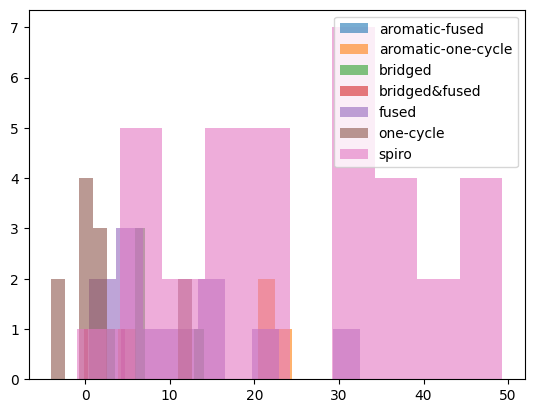

In [28]:
for typ, idxs in STR_EN.groupby("label").groups.items():
    plt.hist(STR_EN.loc[idxs,'strain'], alpha=.6, label=typ)
    
plt.legend()


## Variance of each Descriptor

In [29]:
variances = descriptionsScaled.var()

In [30]:
cmap = plt.get_cmap("OrRd")
cmap = truncate_colormap(cmap, minval=.2,  maxval=1)

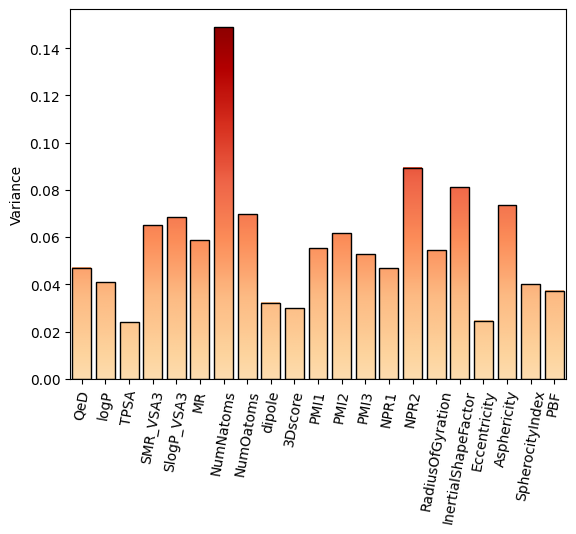

In [ ]:
bar=plt.bar(range(len(variances)), variances, edgecolor="black")
gradientbars_sliced(bar, cmap=cmap)
plt.xticks(range(len(variances)), variances.index, rotation=80)
plt.ylabel("Variance")
plt.xlim([-.5,len(variances)-.5])
# plt.savefig("figures/descriptions/variances.png",bbox_inches="tight")
plt.show()

# Correlation

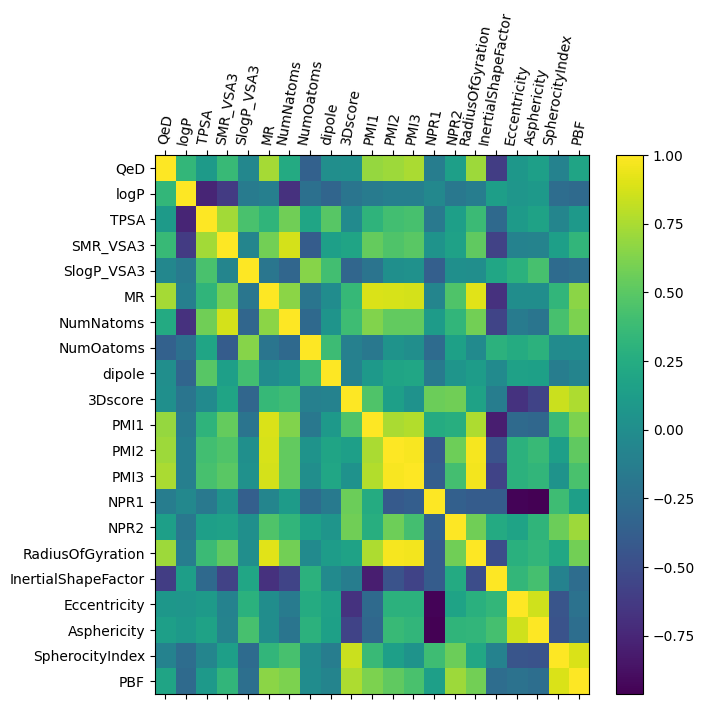

In [ ]:
fig, (ax1) = plt.subplots(ncols=1, figsize=(7, 7))
cbm = ax1.matshow(descriptions.corr(), interpolation=None, aspect='auto')

# plot the colorbar
cb = plt.colorbar(cbm, ax=ax1)
ax1.set_xticks(range(len(descriptions.columns)),descriptions.columns, rotation = 80)
ax1.set_yticks(range(len(descriptions.columns)),descriptions.columns)
# plt.savefig("figures/descriptions/correlation.png",bbox_inches="tight")
plt.show()

# VIF

In [34]:
def getVIF(df):
    VIF = np.linalg.inv(df.corr())
    diag = VIF.diagonal()
    return pd.Series(diag, index=df.columns)

In [35]:
VIF=getVIF(descriptionsScaled)
VIF.sort_values(ascending=False, inplace=True)

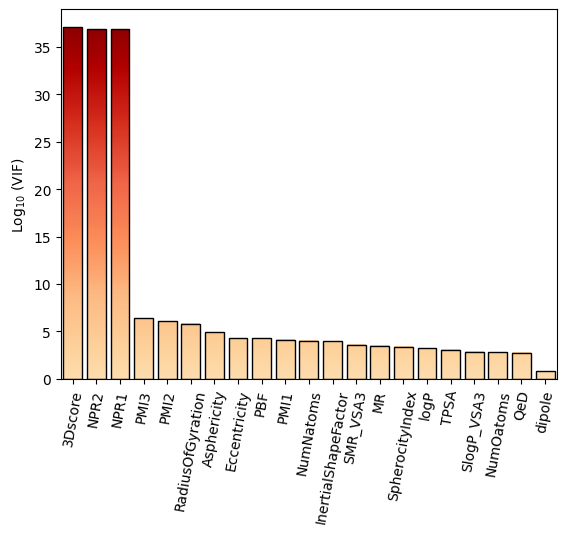

In [ ]:
bar=plt.bar(range(len(VIF)), VIF.apply(np.log), edgecolor="black")
gradientbars_sliced(bar, cmap=cmap)
plt.xticks(range(len(VIF)), VIF.index, rotation=80)
plt.ylabel("Log$_{10}$ (VIF)")
plt.xlim([-.5,len(VIF)-.5])
# plt.savefig("figures/descriptions/vif.png",bbox_inches="tight")
plt.show()

In [38]:
descriptionsScaled.loc[:,VIF.apply(np.log) >= 5].columns.tolist()

['3Dscore', 'PMI2', 'PMI3', 'NPR1', 'NPR2', 'RadiusOfGyration']

# Conclusion about features TO DROP !

In [39]:
features_to_drop = descriptionsScaled.loc[:,VIF.apply(np.log) >= 5].columns.tolist()
features_to_drop

['3Dscore', 'PMI2', 'PMI3', 'NPR1', 'NPR2', 'RadiusOfGyration']

In [42]:
descriptions_selected = descriptions.drop(columns=features_to_drop)
# descriptions_selected.to_csv('data/computed/descripted_def.csv')
descriptions_selected

,QeD,logP,TPSA,SMR_VSA3,SlogP_VSA3,MR,NumNatoms,NumOatoms,dipole,PMI1,InertialShapeFactor,Eccentricity,Asphericity,SpherocityIndex,PBF
smiles,,,,,,,,,,,,,,,
C1NCC12CNO2,0.403605,-1.1368,33.29,10.782935,4.837589,24.6884,2,1,3.87714,81.244835,0.012257,0.945469,0.335358,0.507082,0.718026
C1NCC12CNC2,0.413406,-0.8208,24.06,10.619627,0.000000,28.1724,2,0,1.99457,85.552443,0.011604,0.941199,0.319372,0.661015,0.766013
C1NCC12COC2,0.446167,-0.3938,21.26,5.309813,4.736863,26.1217,1,1,2.52334,82.895966,0.012035,0.946231,0.338602,0.737560,0.798354
C1CC2(CNC2)N1,0.419327,-0.6783,24.06,10.619627,0.000000,28.2204,2,0,2.26480,86.138871,0.011504,0.937728,0.307329,0.539355,0.699706
C1CNC2(C1)CNC2,0.449822,-0.2882,24.06,10.619627,0.000000,32.8374,2,0,1.15946,120.985019,0.007779,0.931523,0.279286,0.605799,0.834604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C1NCC12CN2,0.366447,-1.0684,33.97,10.619627,0.000000,23.6034,2,0,2.80086,63.887166,0.014035,0.938969,0.297353,0.448359,0.647464
C1CC12CNC2,0.445886,0.3698,12.03,5.309813,0.000000,24.5367,1,0,1.48063,66.686223,0.013577,0.934704,0.284426,0.529917,0.712683
C1CC2(C1)CO2,0.397789,0.9393,12.53,0.000000,4.736863,22.5340,0,1,2.19762,65.631702,0.013647,0.935161,0.284896,0.426321,0.593223


## Distribution of some Descriptors

In [43]:
blueMap  = truncate_colormap( plt.get_cmap("Blues"), minval=.2 )
orangeMap = truncate_colormap( plt.get_cmap("Oranges"), minval=.2 )

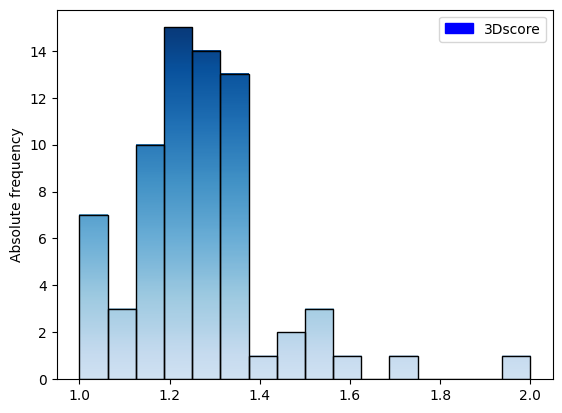

In [ ]:
*_,bar3D = plt.hist(descriptions["3Dscore"], bins = 16, edgecolor="black", range=(1,2), label="3Dscore")
gradientbars_sliced(bar3D, blueMap)
plt.ylabel("Absolute frequency")
leg = plt.legend()
leg.legend_handles[0].set_color('blue')

arrowprops = dict(
    arrowstyle="-",
    color="blue",)

# PBF and QeD

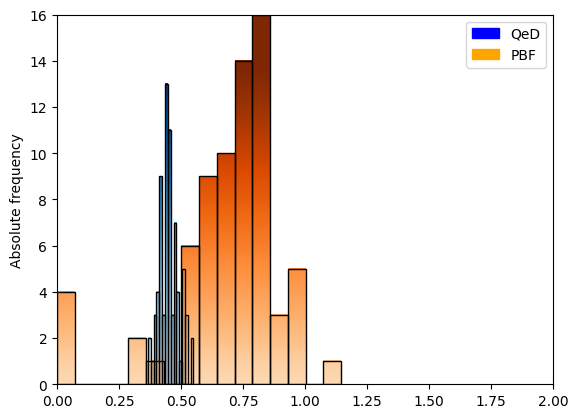

In [ ]:
*_,bar3D_qed = plt.hist(descriptions["QeD"], bins = 16, edgecolor="black", label="QeD")
gradientbars_sliced(bar3D_qed, blueMap)

*_,bar3D_pbf = plt.hist(descriptions["PBF"], bins = 16, edgecolor="black", label="PBF")
gradientbars_sliced(bar3D_pbf, orangeMap)

leg = plt.legend()
leg.legend_handles[0].set_color('blue')
leg.legend_handles[1].set_color('orange')

plt.ylabel("Absolute frequency")
plt.xlim(0, 2)
plt.ylim(None, bar3D_pbf.datavalues.max())